In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import xesmf as xe

In [2]:
PATH = '/glade/derecho/scratch/mmarkina/archive/a.e30.A_JRA.TL319_t232.time_varying_HadOIBl_3hr_output/cpl/hist/'
filename = 'a.e30.A_JRA.TL319_t232.time_varying_HadOIBl_3hr_output.cpl.hi.1962-01-01-00000.nc'

In [3]:
ocn_swnet = xr.open_dataset(PATH + filename)['ocnExp_Foxx_swnet'].isel(time=0, drop = True)
atm_swnet = xr.open_dataset(PATH + filename)['atmImp_Faxa_swnet'].isel(time=0, drop = True)

ocn_lat = xr.open_dataset(PATH + filename)['ocnExp_lat'].isel(time=0, drop = True)
atm_lat = xr.open_dataset(PATH + filename)['atmImp_lat'].isel(time=0, drop = True)

In [4]:
mask = xr.open_dataset(PATH + filename, engine="netcdf4")['ocnImp_So_omask'].isel(time=0, drop = True).rename({"ocnImp_ny": "ocnExp_ny", "ocnImp_nx": "ocnExp_nx"})


<xarray.DataArray 'ocnExp_Foxx_swnet' ()> Size: 8B
array(224.25643895)

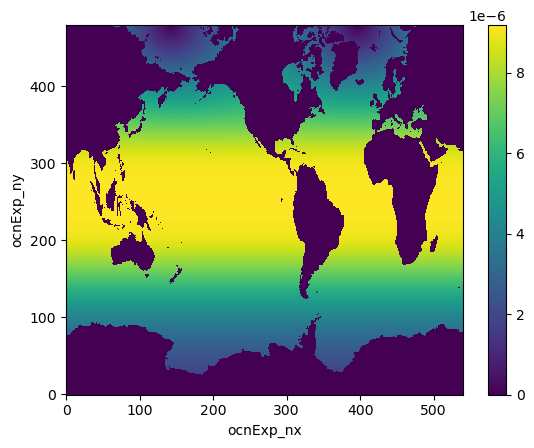

In [5]:
weights = np.cos(np.deg2rad(ocn_lat)) * mask

# Expand dimensions to match the dataset
weights = weights / weights.sum()  # Normalize so they sum to 1
weights = weights.broadcast_like(ocn_swnet)  # Ensure shape matches the data variable

weights.plot()

ocn_mean = ocn_swnet.weighted(weights).mean(dim=["ocnExp_nx", "ocnExp_ny"])
ocn_mean

In [28]:
%%time

lat_in = xr.open_dataset(PATH + filename)['ocnExp_lat'].isel(time=0, drop = True)
lon_in = xr.open_dataset(PATH + filename)['ocnExp_lon'].isel(time=0, drop = True) % 360

mask_in = xr.DataArray(mask.values, dims=("y", "x"),
                       coords={"lon": (("y", "x"), lon_in.values), "lat": (("y", "x"), lat_in.values)},
                       name="mask")


lat_out = xr.open_dataset(PATH + filename)['atmImp_lat'].isel(time=0, drop = True)
lon_out = xr.open_dataset(PATH + filename)['atmImp_lon'].isel(time=0, drop = True)

# Create xESMF regridder for curvilinear grid
grid_in = xr.Dataset({"lat": (("y", "x"), lat_in.values), "lon": (("y", "x"), lon_in.values)})
grid_out = xr.Dataset({"lat": (("y", "x"), lat_out.values), "lon": (("y", "x"), lon_out.values)})

regridder = xe.Regridder(grid_in, grid_out, "nearest_s2d")  # 'nearest_s2d' is best for masks

# Apply regridding
mask_out = regridder(mask_in)
mask_out = mask_out.rename("mask")  # Explicitly set the name

# Display the regridded mask
print(mask_out)


<xarray.DataArray 'mask' (y: 320, x: 640)> Size: 2MB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]])
Dimensions without coordinates: y, x
Attributes:
    regrid_method:  nearest_s2d
CPU times: user 1.66 s, sys: 21.6 ms, total: 1.69 s
Wall time: 3.54 s


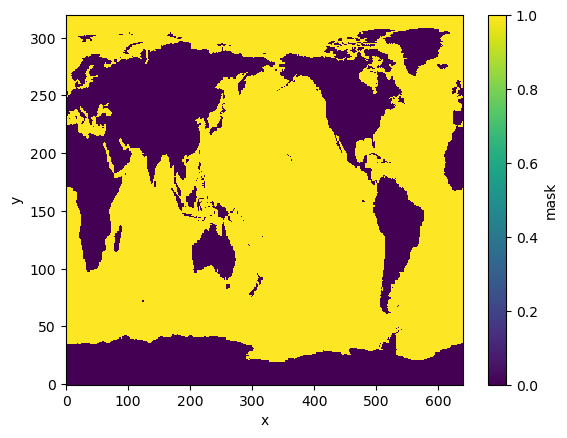

In [29]:
mask_out.plot()

In [31]:
mask_out_da = xr.DataArray(mask_out.values, dims=("y", "x"),
                       coords={"lon": (("y", "x"), lon_out.values), "lat": (("y", "x"), lat_out.values)},
                       name="mask")


In [30]:
mask_out_da.to_netcdf("/glade/u/home/mmarkina/Code/atmImp_mask.nc")

In [ ]:
# mask_atm_raw = xr.open_dataset("/glade/u/home/mmarkina/Code/atmImp_mask.nc", engine="netcdf4")['ocnImp_So_omask']


In [6]:
# # Regridding ocnImp mask to atmImp grid (they have different dimensions) - alternative methid with cdo

# mask = xr.open_dataset(PATH + filename, engine="netcdf4")['ocnImp_So_omask'].isel(time=0, drop = True).rename({"ocnImp_ny": "ocnExp_ny", "ocnImp_nx": "ocnExp_nx"})

# mask['lat'] = xr.open_dataset(PATH + filename)['ocnExp_lat'].isel(time=0, drop = True)
# mask['lon'] = xr.open_dataset(PATH + filename)['ocnExp_lon'].isel(time=0, drop = True) % 360



# mask.to_netcdf("/glade/u/home/mmarkina/Code/ocnImp_mask.nc")


# # Load new lat/lon grid from file
# ds_new = xr.open_dataset(PATH+filename)  # Your file with target grid
# lat_new = ds_new["atmImp_lat"].isel(time=0, drop=True).values  # (320, 480)
# lon_new = ds_new["atmImp_lon"].isel(time=0, drop=True).values  % 360 # (320, 480)

# # Flatten arrays to 1D
# lat_flat = lat_new.flatten()
# lon_flat = lon_new.flatten()

# # Write to a CDO grid file
# with open("/glade/u/home/mmarkina/Code/new_grid.txt", "w") as f:
#     f.write("gridtype = unstructured\n")
#     f.write(f"gridsize = {len(lat_flat)}\n")
#     f.write("xvals = " + " ".join(map(str, lon_flat)) + "\n")
#     f.write("yvals = " + " ".join(map(str, lat_flat)) + "\n")


# # ncatted -O -a standard_name,lon,o,c,longitude ocnImp_mask.nc
# # ncatted -O -a units,lon,o,c,degrees_E ocnImp_mask.nc
# # ncatted -O -a long_name,lon,o,c,longitude ocnImp_mask.nc
# # cdo remapnn,new_grid.txt ocnImp_mask.nc atmImp_mask.nc

In [7]:
mask_atm_raw = xr.open_dataset("/glade/u/home/mmarkina/Code/atmImp_mask.nc", engine="netcdf4")['ocnImp_So_omask']

mask_atm = mask_atm_raw.values.reshape(320,640)
lon_atm = mask_atm_raw.lon.values.reshape(320,640)
lat_atm = mask_atm_raw.lat.values.reshape(320,640)

mask_atm_new = np.empty(np.shape(mask_atm))
lat_atm_new = np.empty(np.shape(lat_atm))
lon_atm_new = np.empty(np.shape(lon_atm))

In [17]:
lon_atm_new[:, :509] = lon_atm[:,131:]
lon_atm_new[:, 509:] = lon_atm[:,:131]

lat_atm_new = lat_atm

mask_atm_new[:, :509] = mask_atm[:,131:]
mask_atm_new[:, 509:] = mask_atm[:,:131]

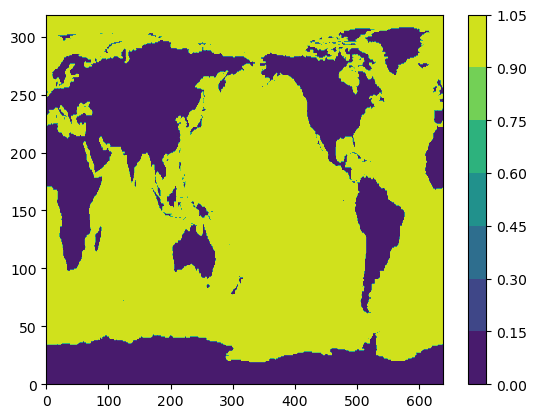

In [10]:
plt.contourf(mask_atm)
plt.colorbar()

<xarray.DataArray 'atmImp_Faxa_swnet' ()> Size: 8B
array(205.66651589)

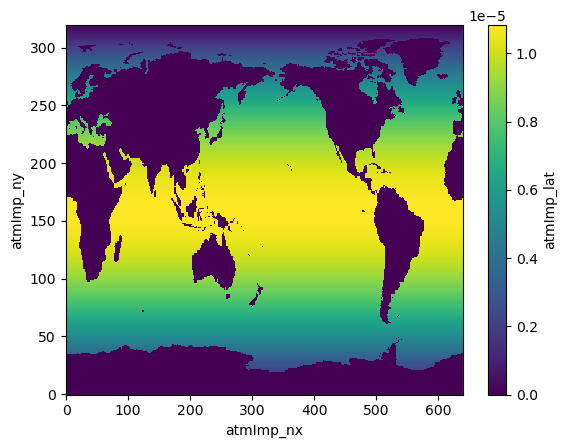

In [11]:
weights = np.cos(np.deg2rad(atm_lat)) * mask_atm

# Expand dimensions to match the dataset
weights = weights / weights.sum()  # Normalize so they sum to 1
weights = weights.broadcast_like(atm_swnet)  # Ensure shape matches the data variable

weights.plot()

atm_mean = atm_swnet.weighted(weights).mean(dim=["atmImp_nx", "atmImp_ny"])
atm_mean

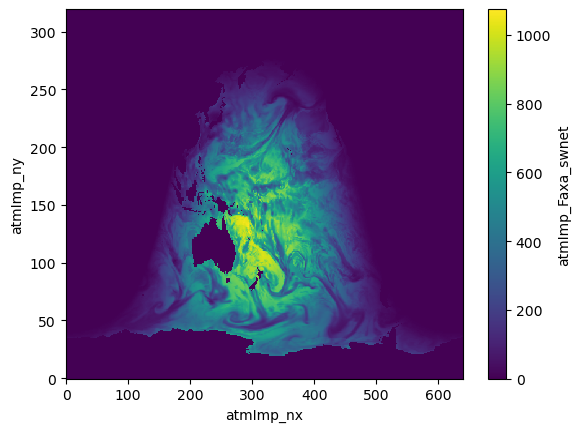

In [12]:
(atm_swnet*mask_atm).plot()

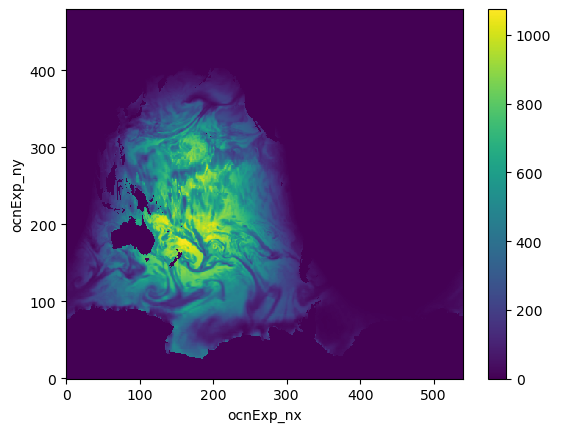

In [16]:
(ocn_swnet*mask).plot()

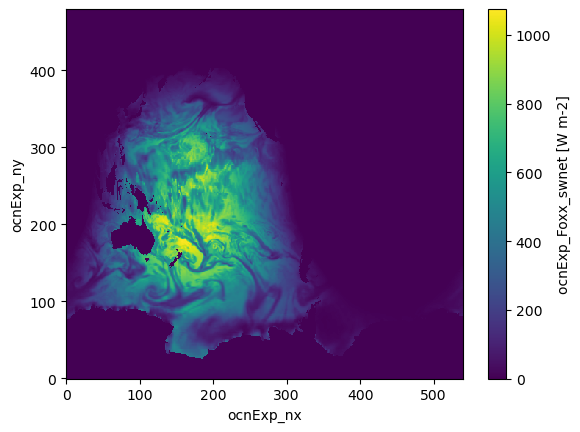

In [15]:
ocn_swnet.plot()